# Sprawdzenie optymalnej liczby kroków treningu

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IMG_DIR = "../docs/tex/img"

ROUTE_LABELS_PL = {
    "light": "lekki",
    "medium": "średni",
    "heavy": "wysoki",
    "random": "zmienny",
}
ROUTE_ORDER_PL = ["lekki", "średni", "wysoki", "zmienny"]

DEMAND_PL = {"low": "lekki", "medium": "średni", "high": "wysoki", "random": "zmienny"}
DEMAND_ORDER_PL = ["lekki", "średni", "wysoki", "zmienny"]

METHOD_PL = {
    "fixed": "stałoczasowy",
    "actuated": "akomodacyjny",
    "dqn": "DQN",
    "dqn-explore1e-1": "DQN niestabilny",
}


def add_route_label(frame: pd.DataFrame) -> pd.DataFrame:
    label = (
        frame["route_file"]
        .str.replace("routes_valid_", "", regex=False)
        .str.replace(".rou", "", regex=False)
    )
    frame["route_label"] = label.map(lambda x: ROUTE_LABELS_PL.get(x, x))
    return frame


def short_name(model_name: str) -> str:
    return str(model_name).replace("dqn_fixed_", "").replace("_225k", "").replace(".zip", "")


# Wczytaj i przetwórz dane
df = pd.read_csv("validate_steps.csv")


def parse_model_metadata(model_name: str):
    name = str(model_name).replace(".zip", "")
    traffic_type = "fixed" if "fixed" in name else "random" if "random" in name else "unknown"
    match = re.search(r"_(\d+)([kKmM]?)_steps$", name) or re.search(r"_(\d+)([kKmM]?)$", name)
    if not match:
        return traffic_type, None
    steps = int(match.group(1))
    suffix = match.group(2).lower()
    if suffix == "k":
        steps *= 1_000
    elif suffix == "m":
        steps *= 1_000_000
    return traffic_type, steps


meta = df["model_name"].apply(parse_model_metadata)
df[["traffic_type", "steps"]] = pd.DataFrame(meta.tolist(), index=df.index)
df = df[df["traffic_type"].isin(["fixed", "random"]) & df["steps"].notna()].copy()
df["steps"] = df["steps"].astype(int)
df = add_route_label(df)


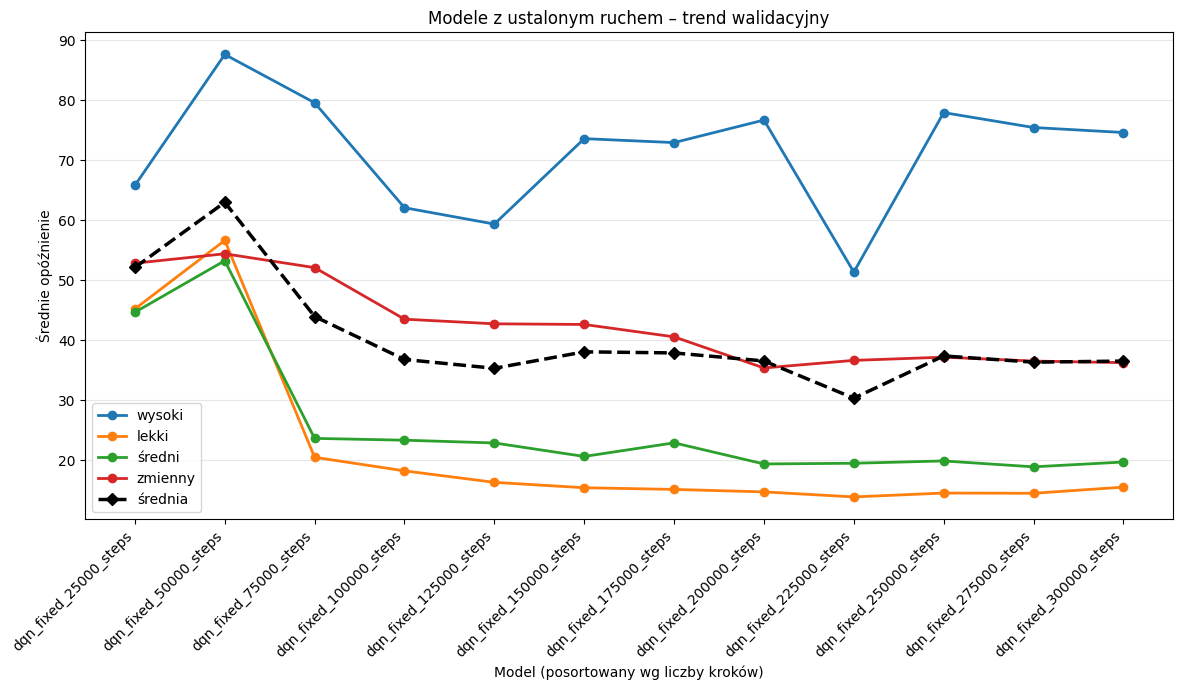

Modele ustalone:
            model_name  steps  mean_delay  poprawa_vs_poprzedni
 dqn_fixed_25000_steps  25000   52.123552                   NaN
 dqn_fixed_50000_steps  50000   62.977264            -10.853712
 dqn_fixed_75000_steps  75000   43.942762             19.034502
dqn_fixed_100000_steps 100000   36.778505              7.164256
dqn_fixed_125000_steps 125000   35.310517              1.467988
dqn_fixed_150000_steps 150000   38.055818             -2.745301
dqn_fixed_175000_steps 175000   37.872497              0.183321
dqn_fixed_200000_steps 200000   36.532417              1.340080
dqn_fixed_225000_steps 225000   30.331744              6.200673
dqn_fixed_250000_steps 250000   37.370732             -7.038989
dqn_fixed_275000_steps 275000   36.330462              1.040270
dqn_fixed_300000_steps 300000   36.514454             -0.183991


In [3]:
# Modele z ustalonym ruchem
fixed = df[df["traffic_type"] == "fixed"].copy()
if not fixed.empty:
    model_order_df = fixed[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in fixed.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = fixed.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="średnia")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (posortowany wg liczby kroków)")
    plt.ylabel("Średnie opóźnienie")
    plt.title("Modele z ustalonym ruchem – trend walidacyjny")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/validate_steps_fixed.png", dpi=150)
    plt.show()

    avg["poprawa_vs_poprzedni"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Modele ustalone:")
    print(avg[["model_name", "steps", "mean_delay", "poprawa_vs_poprzedni"]].to_string(index=False))


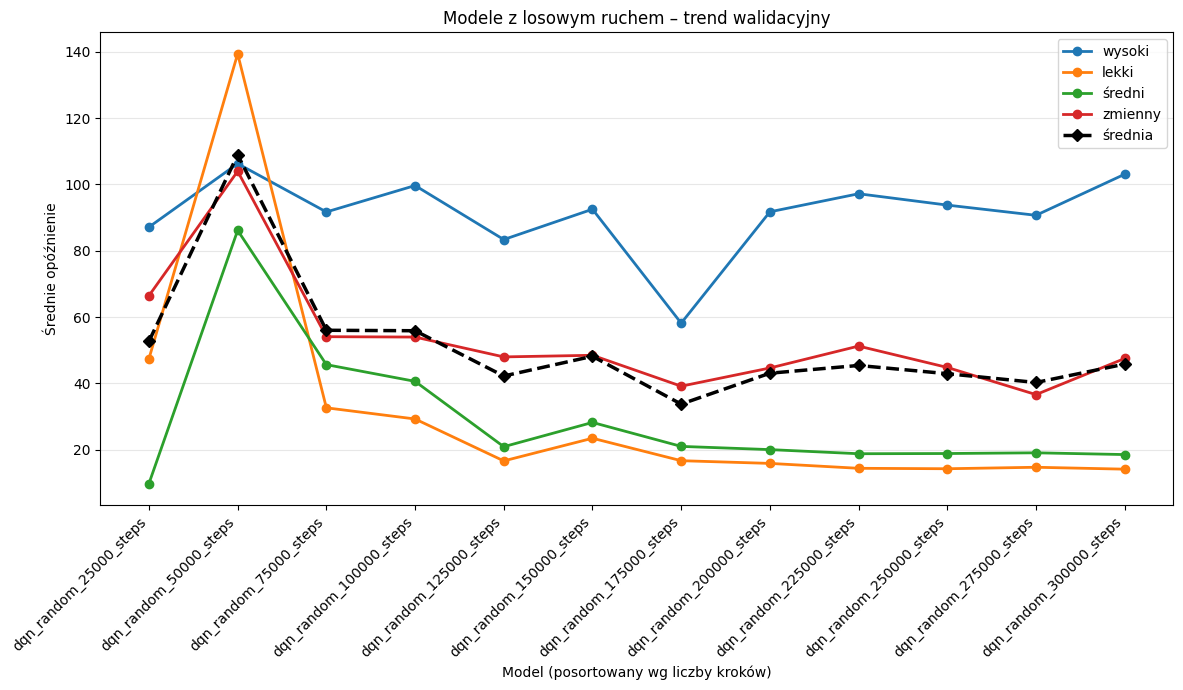

Modele losowe:
             model_name  steps  mean_delay  poprawa_vs_poprzedni
 dqn_random_25000_steps  25000   52.702397                   NaN
 dqn_random_50000_steps  50000  108.931871            -56.229474
 dqn_random_75000_steps  75000   56.008224             52.923647
dqn_random_100000_steps 100000   55.870319              0.137905
dqn_random_125000_steps 125000   42.214147             13.656172
dqn_random_150000_steps 150000   48.160108             -5.945961
dqn_random_175000_steps 175000   33.744618             14.415490
dqn_random_200000_steps 200000   43.062393             -9.317774
dqn_random_225000_steps 225000   45.395669             -2.333277
dqn_random_250000_steps 250000   42.913298              2.482372
dqn_random_275000_steps 275000   40.262390              2.650907
dqn_random_300000_steps 300000   45.804975             -5.542585


In [4]:
# Modele z losowym ruchem
randomized = df[df["traffic_type"] == "random"].copy()
if not randomized.empty:
    model_order_df = randomized[["model_name", "steps"]].drop_duplicates().sort_values("steps")
    step_to_model = dict(zip(model_order_df["steps"], model_order_df["model_name"]))

    plt.figure(figsize=(12, 7))
    for route_label, group in randomized.groupby("route_label", sort=False):
        g = group.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
        plt.plot(g["steps"], g["mean_delay"], marker="o", linewidth=2, label=route_label)

    avg = randomized.groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    plt.plot(avg["steps"], avg["mean_delay"], marker="D", linestyle="--", linewidth=2.5, color="black", label="średnia")

    ticks = sorted(step_to_model.keys())
    plt.xticks(ticks, [step_to_model[s] for s in ticks], rotation=45, ha="right")
    plt.xlabel("Model (posortowany wg liczby kroków)")
    plt.ylabel("Średnie opóźnienie")
    plt.title("Modele z losowym ruchem – trend walidacyjny")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/validate_steps_random.png", dpi=150)
    plt.show()

    avg["poprawa_vs_poprzedni"] = avg["mean_delay"].shift(1) - avg["mean_delay"]
    avg["model_name"] = avg["steps"].map(step_to_model)
    print("Modele losowe:")
    print(avg[["model_name", "steps", "mean_delay", "poprawa_vs_poprzedni"]].to_string(index=False))
else:
    print("Brak danych dla modeli z losowym ruchem.")


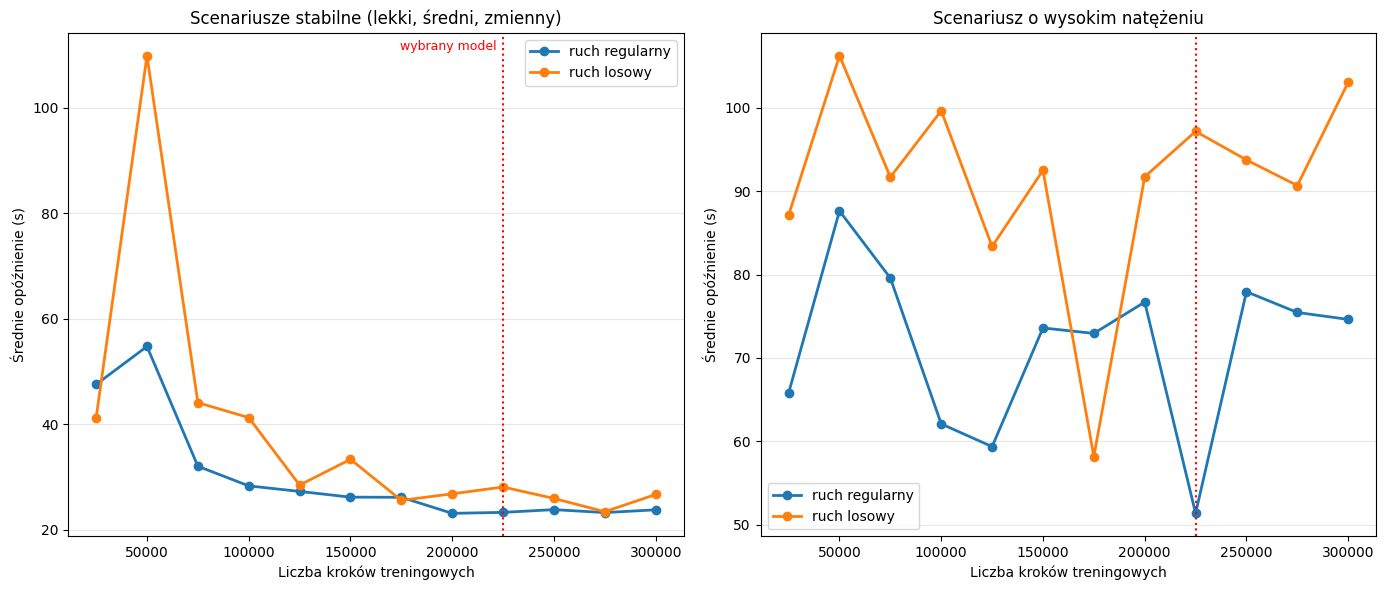

Zbiór regularny, scenariusze stabilne (widoczne plateau):
 steps  mean_delay
 25000   47.565414
 50000   54.759890
 75000   32.065035
100000   28.345369
125000   27.296498
150000   26.209931
175000   26.184398
200000   23.145082
225000   23.326086
250000   23.848323
275000   23.290426
300000   23.813118


In [5]:
# Scenariusze stabilne a scenariusz o wysokim natężeniu
# Uśrednianie wszystkich czterech tras zaciera plateau, bo scenariusz o wysokim natężeniu ma
# wartości kilkukrotnie większe i zdominowałby średnią.
STABILNE = ["lekki", "średni", "zmienny"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
TYPY = [("fixed", "ruch regularny"), ("random", "ruch losowy")]

for traffic_type, opis in TYPY:
    sub = df[df["traffic_type"] == traffic_type]
    if sub.empty:
        continue
    stab = (
        sub[sub["route_label"].isin(STABILNE)]
        .groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    )
    wysoki = (
        sub[sub["route_label"] == "wysoki"]
        .groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
    )
    axes[0].plot(stab["steps"], stab["mean_delay"], marker="o", linewidth=2, label=opis)
    axes[1].plot(wysoki["steps"], wysoki["mean_delay"], marker="o", linewidth=2, label=opis)

axes[0].set_title("Scenariusze stabilne (lekki, średni, zmienny)")
axes[1].set_title("Scenariusz o wysokim natężeniu")
for ax in axes:
    ax.set_xlabel("Liczba kroków treningowych")
    ax.set_ylabel("Średnie opóźnienie (s)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    ax.axvline(225_000, color="red", linestyle=":", linewidth=1.5)

axes[0].annotate("wybrany model", xy=(225_000, axes[0].get_ylim()[1]), xytext=(-5, -12),
                 textcoords="offset points", ha="right", color="red", fontsize=9)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/validate_steps_stabilne_vs_ciezki.png", dpi=150)
plt.show()

print("Zbiór regularny, scenariusze stabilne (widoczne plateau):")
stab_fixed = (
    df[(df["traffic_type"] == "fixed") & df["route_label"].isin(STABILNE)]
    .groupby("steps", as_index=False)["mean_delay"].mean().sort_values("steps")
)
print(stab_fixed.to_string(index=False))


# Potwierdzenie wyboru liczby kroków na wielu ziarnach

Walidacja jednoprzebiegowa jest wrażliwa na losowość symulacji, zwłaszcza na scenariuszu o wysokim natężeniu.
Trzech kandydatów oceniono ponownie na pięciu ziarnach, aby odróżnić rzeczywistą przewagę od szumu.


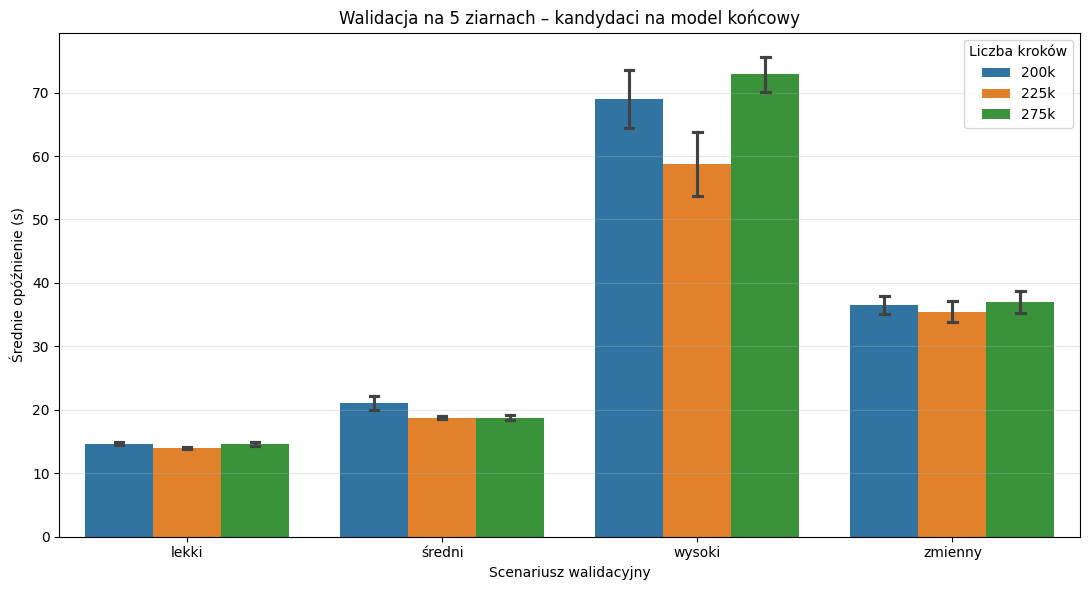

Średnie opóźnienie i odchylenie standardowe (5 ziaren):
              mean                         std                      
route_label  lekki wysoki zmienny średni lekki wysoki zmienny średni
etykieta                                                            
200k         14.65  68.98   36.58  21.03  0.25   4.50    1.41   1.07
225k         13.94  58.76   35.48  18.78  0.18   5.08    1.65   0.29
275k         14.61  72.89   37.00  18.74  0.27   2.74    1.72   0.40

Średnia po wszystkich scenariuszach:
etykieta
200k    35.31
225k    31.74
275k    35.81


In [6]:
# Walidacja wieloziarnowa kandydatów na model końcowy
seeds_df = add_route_label(pd.read_csv("validate_steps_check_seed.csv"))
seeds_df["kroki"] = seeds_df["model_name"].str.extract(r"_(\d+)_steps").astype(int)
seeds_df["etykieta"] = (seeds_df["kroki"] // 1000).astype(str) + "k"

kolejnosc = [f"{k // 1000}k" for k in sorted(seeds_df["kroki"].unique())]

plt.figure(figsize=(11, 6))
sns.barplot(data=seeds_df, x="route_label", y="mean_delay", hue="etykieta",
            order=ROUTE_ORDER_PL, hue_order=kolejnosc, errorbar="sd", capsize=0.1)
plt.title("Walidacja na 5 ziarnach – kandydaci na model końcowy")
plt.xlabel("Scenariusz walidacyjny")
plt.ylabel("Średnie opóźnienie (s)")
plt.legend(title="Liczba kroków")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/validate_steps_wieloziarnowa.png", dpi=150)
plt.show()

podsumowanie = (
    seeds_df.groupby(["etykieta", "route_label"])["mean_delay"]
    .agg(["mean", "std"]).round(2)
    .unstack("route_label")
    .reindex(kolejnosc)
)
srednia = seeds_df.groupby(["etykieta", "route_file"])["mean_delay"].mean().groupby("etykieta").mean()
print("Średnie opóźnienie i odchylenie standardowe (5 ziaren):")
print(podsumowanie.to_string())
print("\nŚrednia po wszystkich scenariuszach:")
print(srednia.reindex(kolejnosc).round(2).to_string())


# Strojenie hiperparametrów modelu z ustalonym ruchem

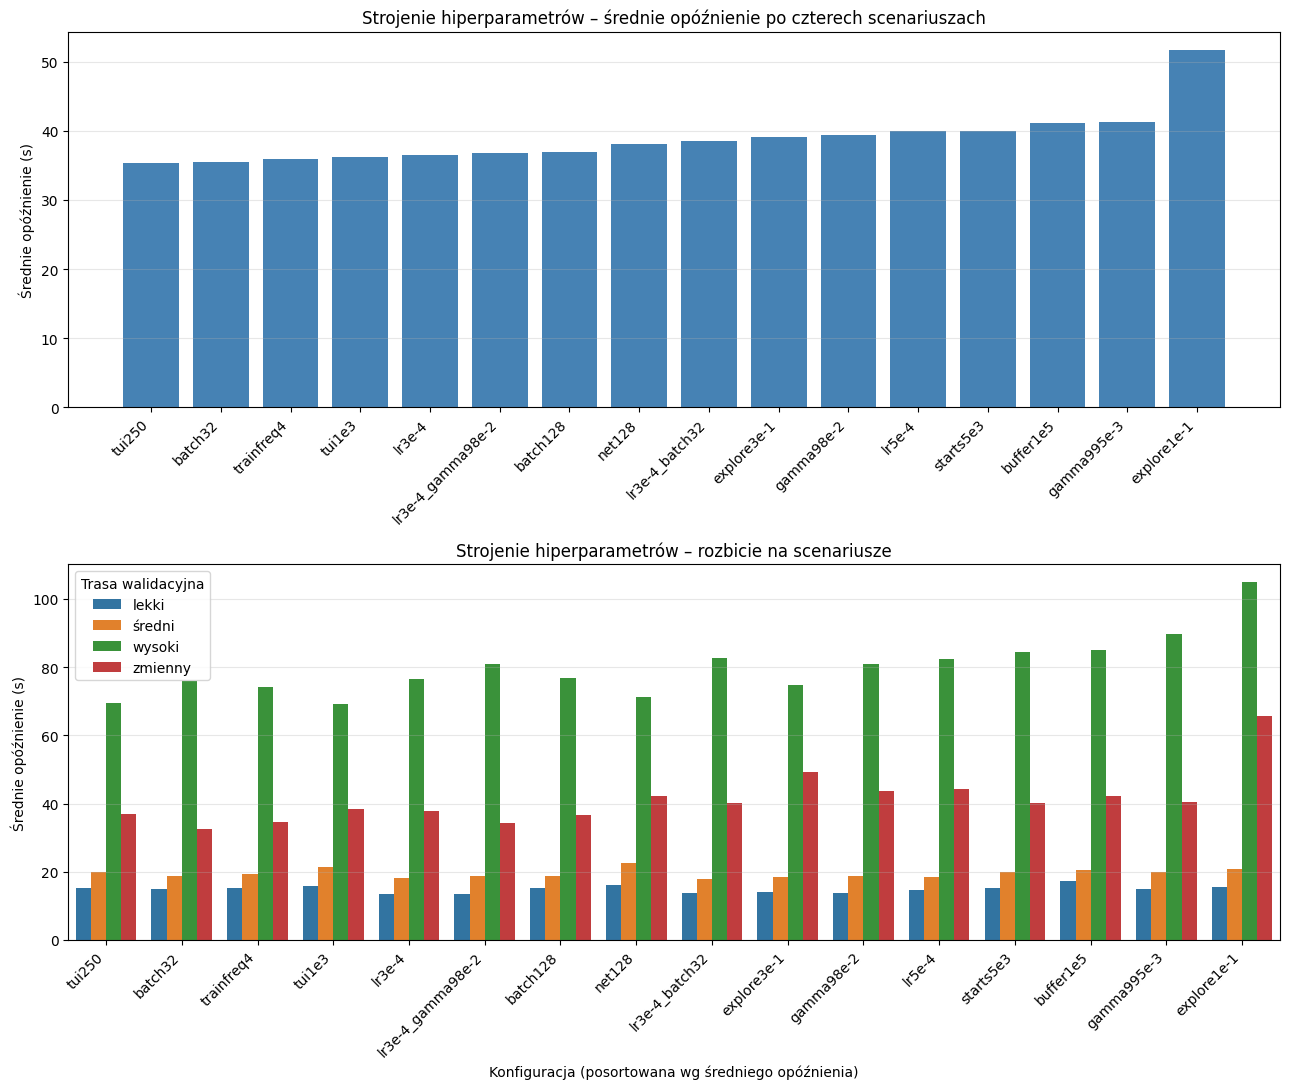

Ranking konfiguracji wg średniego opóźnienia (niższe = lepsze):
konfiguracja
tui250               35.32
batch32              35.42
trainfreq4           35.89
tui1e3               36.15
lr3e-4               36.51
lr3e-4_gamma98e-2    36.84
batch128             36.90
net128               38.05
lr3e-4_batch32       38.58
explore3e-1          39.09
gamma98e-2           39.33
lr5e-4               39.91
starts5e3            40.01
buffer1e5            41.17
gamma995e-3          41.28
explore1e-1          51.70


In [7]:
# Niezależne porównanie hiperparametrów
# Wykres słupkowy, a nie liniowy: kolejne konfiguracje nie tworzą ciągu,
# więc łączenie ich linią sugerowałoby trend, którego nie ma.
hp = add_route_label(pd.read_csv("validation_params.csv"))
hp["konfiguracja"] = hp["model_name"].map(short_name)

pivot = hp.pivot_table(index="konfiguracja", columns="route_label", values="mean_delay", aggfunc="mean")
pivot["śr. opóźnienie"] = pivot[ROUTE_ORDER_PL].mean(axis=1)
pivot = pivot.sort_values("śr. opóźnienie")

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

axes[0].bar(pivot.index, pivot["śr. opóźnienie"], color="steelblue")
axes[0].set_title("Strojenie hiperparametrów – średnie opóźnienie po czterech scenariuszach")
axes[0].set_ylabel("Średnie opóźnienie (s)")
axes[0].tick_params(axis="x", rotation=45)
for label in axes[0].get_xticklabels():
    label.set_ha("right")
axes[0].grid(axis="y", alpha=0.3)

dane_long = pivot[ROUTE_ORDER_PL].reset_index().melt(
    id_vars="konfiguracja", var_name="Trasa walidacyjna", value_name="mean_delay"
)
sns.barplot(data=dane_long, x="konfiguracja", y="mean_delay", hue="Trasa walidacyjna",
            order=pivot.index, hue_order=ROUTE_ORDER_PL, ax=axes[1])
axes[1].set_title("Strojenie hiperparametrów – rozbicie na scenariusze")
axes[1].set_xlabel("Konfiguracja (posortowana wg średniego opóźnienia)")
axes[1].set_ylabel("Średnie opóźnienie (s)")
axes[1].tick_params(axis="x", rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha("right")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hyperparameter_tuning.png", dpi=150)
plt.show()

print("Ranking konfiguracji wg średniego opóźnienia (niższe = lepsze):")
print(pivot["śr. opóźnienie"].round(2).to_string())


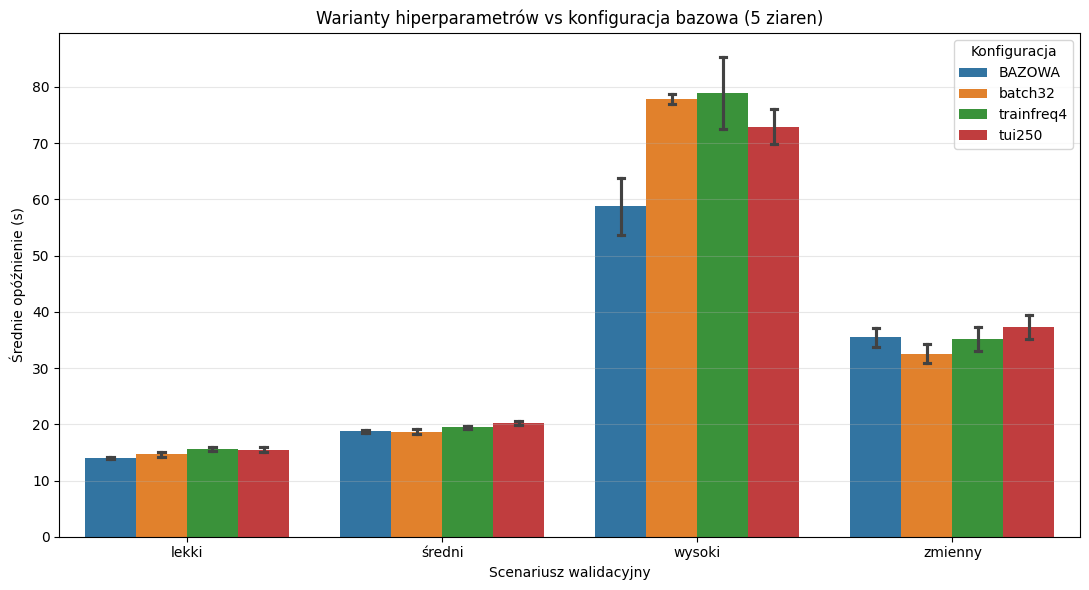

Porównanie na pięciu ziarnach:
route_label   lekki  średni  wysoki  zmienny  średnia  vs bazowa
konfiguracja                                                    
BAZOWA        13.94   18.78   58.76    35.48    31.74       0.00
batch32       14.64   18.65   77.89    32.58    35.94       4.20
trainfreq4    15.66   19.45   78.97    35.13    37.31       5.57
tui250        15.51   20.15   72.92    37.28    36.46       4.72


In [8]:
# Trzy najlepsze warianty vs konfiguracja bazowa, po 5 ziaren każdy
# Dopiero takie zestawienie jest symetryczne: wcześniej baza miała 5 przebiegów,
# a warianty po jednym.
warianty = add_route_label(pd.read_csv("validation_params_check_seed.csv"))
warianty["konfiguracja"] = warianty["model_name"].map(short_name)

baza = add_route_label(pd.read_csv("validate_steps_check_seed.csv"))
baza = baza[baza["model_name"] == "dqn_fixed_225000_steps"].copy()
baza["konfiguracja"] = "BAZOWA"

porownanie = pd.concat([baza, warianty], ignore_index=True)
kolejnosc_konf = ["BAZOWA"] + sorted(warianty["konfiguracja"].unique())

plt.figure(figsize=(11, 6))
sns.barplot(data=porownanie, x="route_label", y="mean_delay", hue="konfiguracja",
            order=ROUTE_ORDER_PL, hue_order=kolejnosc_konf, errorbar="sd", capsize=0.1)
plt.title("Warianty hiperparametrów vs konfiguracja bazowa (5 ziaren)")
plt.xlabel("Scenariusz walidacyjny")
plt.ylabel("Średnie opóźnienie (s)")
plt.legend(title="Konfiguracja")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/hyperparameter_wieloziarnowa.png", dpi=150)
plt.show()

zestawienie = (
    porownanie.groupby(["konfiguracja", "route_label"])["mean_delay"]
    .mean().unstack("route_label")[ROUTE_ORDER_PL]
)
zestawienie["średnia"] = zestawienie.mean(axis=1)
zestawienie = zestawienie.reindex(kolejnosc_konf).round(2)
zestawienie["vs bazowa"] = (zestawienie["średnia"] - zestawienie.loc["BAZOWA", "średnia"]).round(2)
print("Porównanie na pięciu ziarnach:")
print(zestawienie.to_string())


# Wizualizacja wyników końcowych

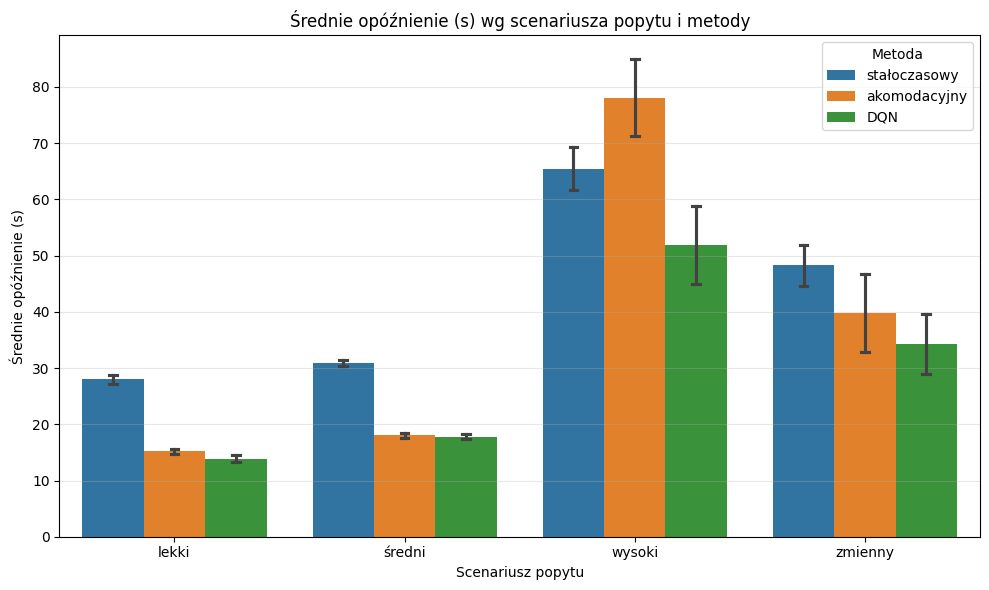

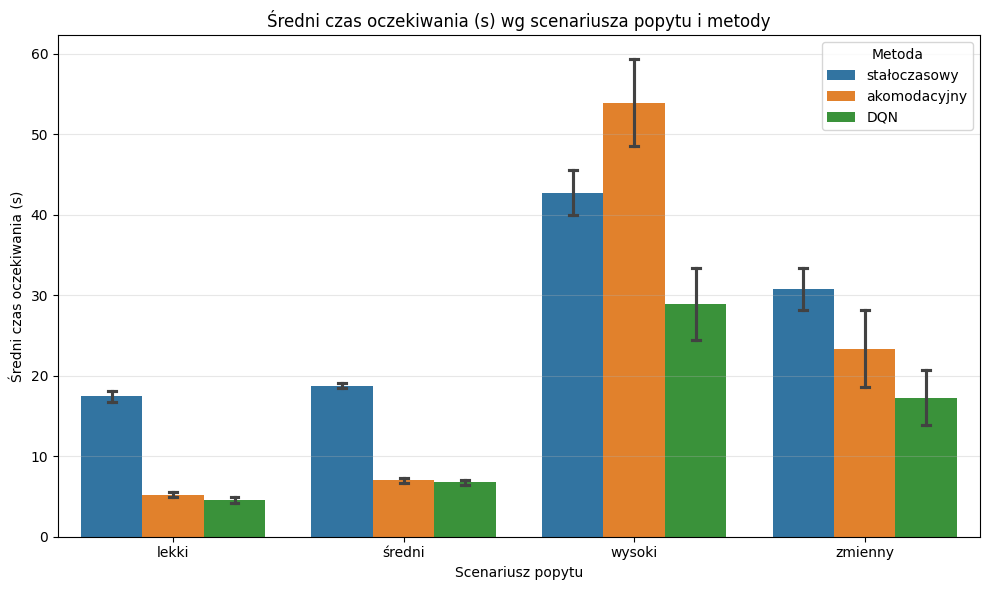

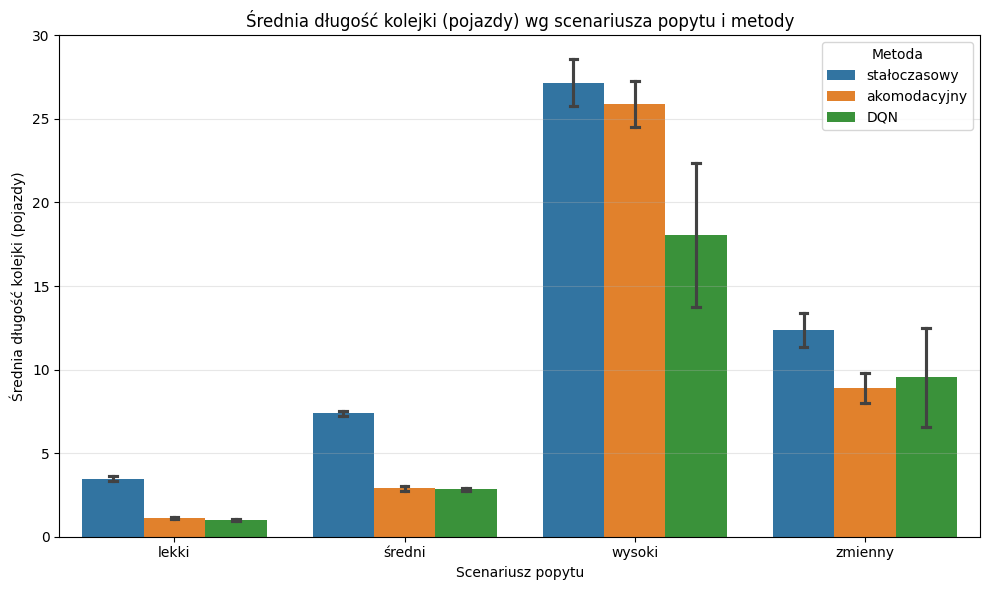

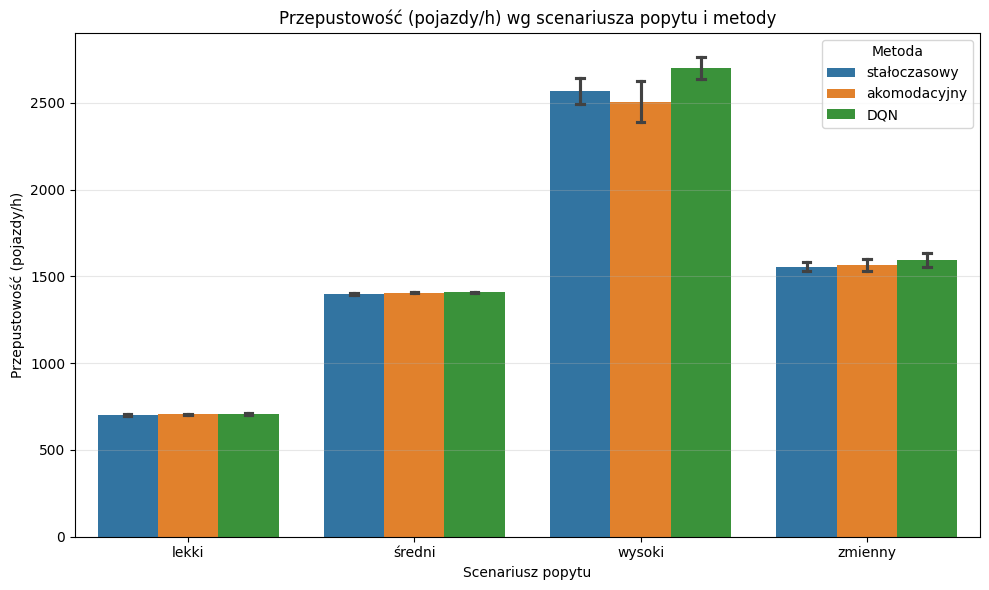

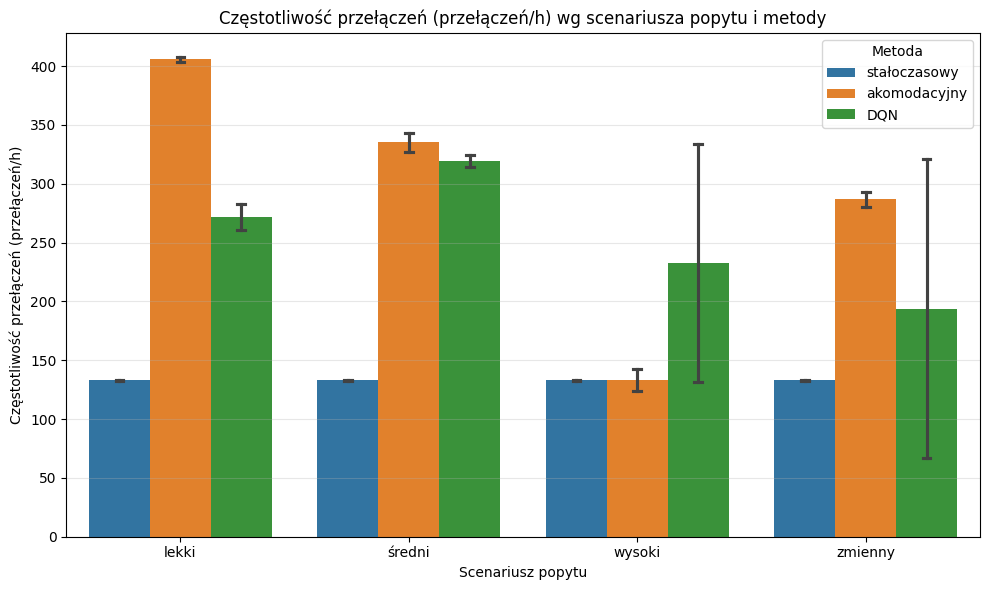

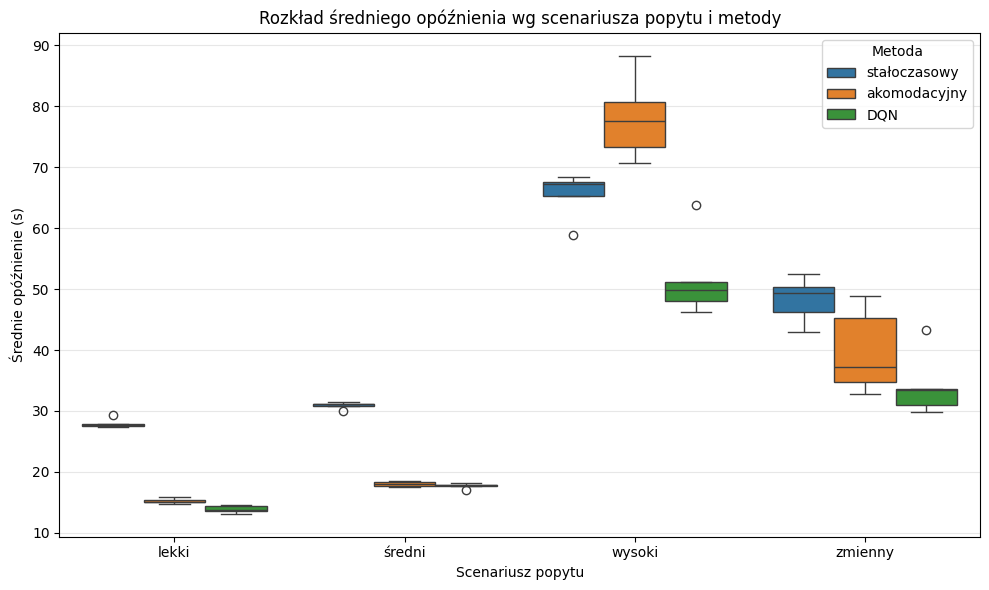

Średnie wartości metryk na zbiorze testowym:
                      mean_delay  mean_waiting  mean_queue  throughput  switching_freq
method       demand                                                                   
stałoczasowy lekki         28.00         17.43        3.48      700.75          132.95
             średni        30.91         18.77        7.37     1399.00          132.90
             wysoki        65.45         42.76       27.17     2569.91          133.04
             zmienny       48.25         30.74       12.37     1556.97          132.78
akomodacyjny lekki         15.22          5.21        1.13      705.48          405.63
             średni        18.02          6.99        2.90     1405.34          335.33
             wysoki        78.07         53.92       25.88     2507.31          133.13
             zmienny       39.76         23.35        8.88     1567.39          286.82
DQN          lekki         13.90          4.60        1.01      707.02          272.0

In [9]:
# Porównanie trzech metod sterowania na zbiorze testowym
res = pd.read_csv("results.csv")
res = res[res["method"] != "dqn-explore1e-1"].copy()
res["demand"] = res["demand"].map(lambda x: DEMAND_PL.get(x, x))
res["method"] = res["method"].map(lambda x: METHOD_PL.get(x, x))
method_order = ["stałoczasowy", "akomodacyjny", "DQN"]

metrics = [
    ("mean_delay", "Średnie opóźnienie (s)", "mean_delay"),
    ("mean_waiting", "Średni czas oczekiwania (s)", "mean_waiting"),
    ("mean_queue", "Średnia długość kolejki (pojazdy)", "mean_queue"),
    ("throughput", "Przepustowość (pojazdy/h)", "throughput"),
    ("switching_freq", "Częstotliwość przełączeń (przełączeń/h)", "switching_freq"),
]

for col, ylabel, fname in metrics:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res, x="demand", y=col, hue="method", order=DEMAND_ORDER_PL,
                hue_order=method_order, errorbar="sd", capsize=0.1)
    plt.title(f"{ylabel} wg scenariusza popytu i metody")
    plt.ylabel(ylabel)
    plt.xlabel("Scenariusz popytu")
    plt.legend(title="Metoda")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/results_bar_{fname}_simp.png", dpi=150)
    plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=res, x="demand", y="mean_delay", hue="method",
            order=DEMAND_ORDER_PL, hue_order=method_order)
plt.title("Rozkład średniego opóźnienia wg scenariusza popytu i metody")
plt.ylabel("Średnie opóźnienie (s)")
plt.xlabel("Scenariusz popytu")
plt.legend(title="Metoda")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/results_boxplot_mean_delay_simp.png", dpi=150)
plt.show()

podsum = (
    res.groupby(["method", "demand"])[["mean_delay", "mean_waiting", "mean_queue", "throughput", "switching_freq"]]
    .mean().round(2)
    .reindex(pd.MultiIndex.from_product([method_order, DEMAND_ORDER_PL], names=["method", "demand"]))
)
print("Średnie wartości metryk na zbiorze testowym:")
print(podsum.to_string())


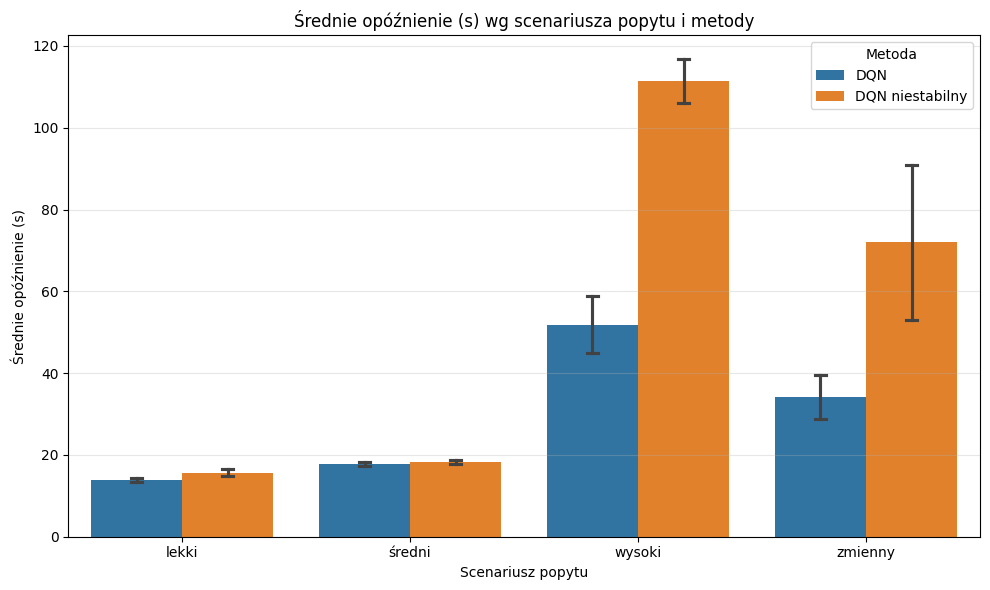

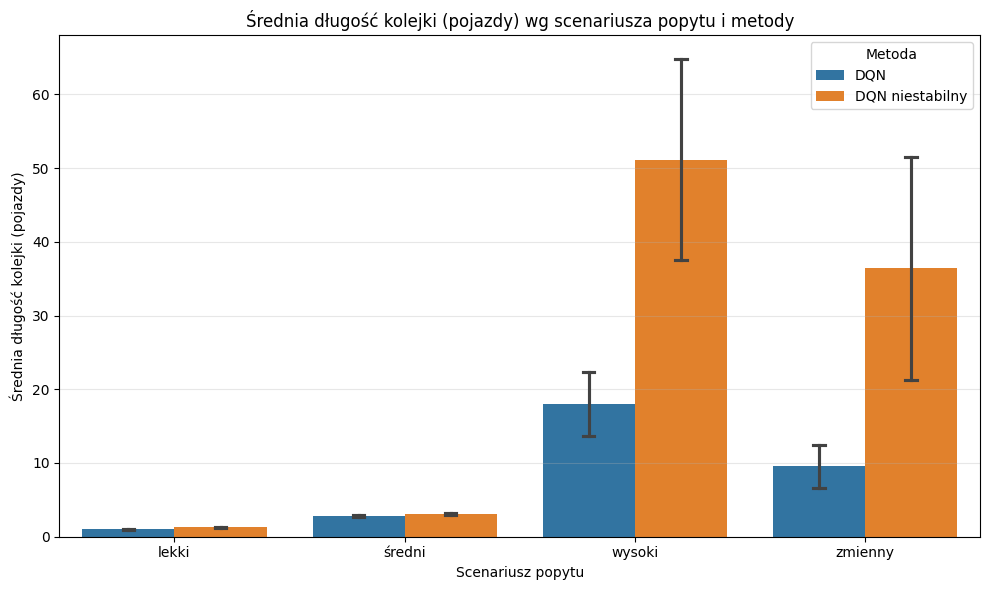

Średnie opóźnienie – model końcowy vs model niestabilny:
demand           lekki  średni  wysoki  zmienny  średnia
method                                                  
DQN              13.90   17.79   51.82    34.23    29.43
DQN niestabilny  15.68   18.38  111.41    71.96    54.36


In [10]:
# Model końcowy vs model o słabych wynikach walidacyjnych
# Sprawdzenie, czy słaba walidacja przekłada się na słabą generalizację na zbiorze testowym.
res2 = pd.read_csv("results.csv")
res2 = res2[res2["method"].isin(["dqn", "dqn-explore1e-1"])].copy()
res2["demand"] = res2["demand"].map(lambda x: DEMAND_PL.get(x, x))
res2["method"] = res2["method"].map(lambda x: METHOD_PL.get(x, x))
method_order_2 = ["DQN", "DQN niestabilny"]

metrics_2 = [
    ("mean_delay", "Średnie opóźnienie (s)", "mean_delay_2"),
    ("mean_queue", "Średnia długość kolejki (pojazdy)", "mean_queue_2"),
]

for col, ylabel, fname in metrics_2:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=res2, x="demand", y=col, hue="method", hue_order=method_order_2,
                order=DEMAND_ORDER_PL, errorbar="sd", capsize=0.1)
    plt.title(f"{ylabel} wg scenariusza popytu i metody")
    plt.ylabel(ylabel)
    plt.xlabel("Scenariusz popytu")
    plt.legend(title="Metoda")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{IMG_DIR}/results_bar_{fname}.png", dpi=150)
    plt.show()

zest = res2.groupby(["method", "demand"])["mean_delay"].mean().unstack("demand")[DEMAND_ORDER_PL]
zest["średnia"] = zest.mean(axis=1)
print("Średnie opóźnienie – model końcowy vs model niestabilny:")
print(zest.reindex(method_order_2).round(2).to_string())
